# NHL Salary Prediction: Эксперименты и анализ моделей (CP2)

## Цель ноутбука

Этот ноутбук документирует полный цикл экспериментов по предсказанию зарплат игроков NHL уже на этапе CP2, где были добавлены модели, тюнинг и немного других признаков.
Так же я делала эксперимент с интерпретацией постановки задачи, о чем тут тоже рассказывается.
Для вратарей также использовалась теперь кросс-валидация.
Здесь в этом ноутбуке собраны результаты всех обученных моделей, SHAP-анализ финальной модели,
разбор ошибок и обоснование выбора модели для деплоя.

## Две постановки задачи

**Постановка А: предсказание текущего контракта**
Статистика сезона N - cap hit сезона N. Классическая регрессия:
по тому что игрок показывает прямо сейчас предсказываем его текущую зарплату.
Выборка: 1829 train / 601 val / 476 test (сезоны 2022–2024 / 2025 / 2026).

**Постановка Б: предсказание будущего контракта**
Статистика сезона N - cap hit сезона N+1, только для игроков у которых контракт
изменился (порог изменения 5%). Более реалистичная с точки зрения практики задача:
предсказать, что получит игрок следующим летом, но гораздо меньше выборка данных, так как не у всех контракт меняется каждый сезон и не все игроки входят во все сезоны, как было выяснено в EDA.
Выборка: 362 train / 172 val / 52 test (сезоны 2022–2023 / 2024 / 2025).

## Данные

| Тип | Train | Val | Test |
|---|---|---|---|
| Скейтеры А | 1829 | 601 | 476 |
| Скейтеры Б | 362 | 172 | 52 |
| Вратари А | CV по 4 сезонам | — | — |
| Вратари Б | CV по 3 сезонам | — | — |

Вратари оцениваются через кросс-валидацию по сезонам — фиксированный тест
(51 и 9 строк соответственно) слишком мал для надёжной оценки.

## Таргет и метрики

Таргет: `log_cap_hit = log1p(cap_hit)`.
При оценке переводим обратно через `expm1` и считаем метрики в USD.

**Приоритетная метрика: MAE** - средняя абсолютная ошибка в долларах, т.к.
интерпретируется напрямую: "модель ошибается в среднем на X долларов".
Дополнительно: RMSE (штраф за крупные ошибки), R2 (доля объяснённой дисперсии),
MAPE (относительная ошибка, позволяет сравнивать постановки А и Б).

## Temporal split для защиты от leakage

Случайный split создаёт утечку: модель видит будущих игроков при обучении.
Наш split строго хронологический: train < val < test по season_year.

## Список моделей

В каждой постановке обучено 15 конфигураций:
- **Baseline**: LinearRegression без feature engineering
- **Дефолтные**: Ridge, ElasticNet, Random Forest, XGBoost, LightGBM, CatBoost
- **Tuned**: те же 4 бустинга + ElasticNet через Optuna (50 trials для А, 30 для Б)
- **Ансамбль**: Stacking (LightGBM + XGBoost + CatBoost + RF -> Ridge meta)
- **Уменьшение размерности**: LightGBM + SelectFromModel, PCA + Ridge

In [7]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import shap
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

root = Path("..")
features_dir = root / "data" / "features"
models_dir = root / "models"
images_dir = root / "report" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

exclude_cols = [
    "playerId", "skaterFullName", "goalieFullName", "lastName",
    "season", "seasonId", "season_year", "teamAbbrevs",
    "positionCode", "shootsCatches", "birthCity", "birthCountry",
    "name_key", "cap_hit", "log_cap_hit",
    "player_name_cw", "team_cw", "position_cw",
    "evPoints", "ppTimeOnIce", "ppTimeOnIcePctPerGame",
    "missedShotWideOfNet", "ppIndividualSatFor",
    "timeOnIce", "completeGames", "gamesPlayed",
    "saves", "regulationWins", "birthCountry", "country_group",
    "cap_pct", "cap_pct_lag1", "salary_cap", "cap_hit_lag1",
    "cap_hit_delta",
]

def get_feature_cols(df, prefix=""):
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    always_exclude = exclude_cols.copy()
    if "B" in prefix:
        always_exclude += ["cap_hit_lag1", "cap_hit_delta", "cap_hit_next"]
    return [c for c in numeric if c not in always_exclude]

def fmt_m(x):
    """Форматирует число в миллионах."""
    return f"${x/1e6:.2f}M"

## Постановка А: предсказание текущего контракта

### Скейтеры

Обучено 15 конфигураций моделей. Ниже полная таблица экспериментов
на val (сезон 2025).

In [2]:
exp_A = pd.read_csv(models_dir / "skaters_experiments.csv")

def highlight_best(df, metric="mae", ascending=True):
    styled = df.copy()
    styled["mae"] = styled["mae"].apply(lambda x: f"${x/1e6:.3f}M")
    styled["rmse"] = styled["rmse"].apply(lambda x: f"${x/1e6:.3f}M")
    styled["r2"] = styled["r2"].round(3)
    styled["mape"] = styled["mape"].round(1).astype(str) + "%"
    return styled[["label", "mae", "rmse", "r2", "mape"]]

display(highlight_best(exp_A))

,label,mae,rmse,r2,mape
0,skaters_baseline_linear,$1.275M,$1.821M,0.603,41.3%
1,skaters_ridge,$1.269M,$1.803M,0.611,40.6%
2,skaters_elasticnet,$2.338M,$3.070M,-0.129,76.6%
3,skaters_random_forest,$1.220M,$1.763M,0.628,35.6%
4,skaters_xgboost,$1.121M,$1.631M,0.681,34.3%
5,skaters_lightgbm,$1.086M,$1.605M,0.692,34.3%
6,skaters_catboost,$1.165M,$1.670M,0.666,34.5%
7,skaters_lightgbm_tuned,$1.089M,$1.590M,0.697,33.1%
8,skaters_xgboost_tuned,$1.063M,$1.581M,0.701,34.0%
9,skaters_catboost_tuned,$1.098M,$1.613M,0.689,35.3%


### Выводы по таблице экспериментов (постановка А, скейтеры)

Линейные модели (baseline, Ridge, ElasticNet) показывают схожие результаты
в диапазоне MAE 1.24–1.27M. Ridge незначительно лучше baseline.
ElasticNet с дефолтными параметрами (alpha=1.0) провалился из-за
слишком сильной L1-регуляризации, обнулившей большинство коэффициентов.
После тюнинга Optuna ElasticNet tuned показал MAE=1.24M.

Деревья и бустинг превосходят линейные модели: LightGBM дефолтный
уже даёт MAE=1.086M против 1.269M у Ridge. Это ожидаемо, т.к. зависимость зарплаты
от признаков нелинейная, и взаимодействия между признаками деревья улавливают автоматически.

Optuna тюнинг дал прирост для XGBoost и небольшой для LightGBM.
CatBoost и Random Forest от тюнинга выиграли меньше, их дефолтные параметры
уже оказались близки к оптимальным для этой задачи.

Stacking (LightGBM + XGBoost + CatBoost + RF -> Ridge) показал MAE=1.070M и это уже
близко к лучшему XGBoost tuned (1.063M). Ансамбль немного сглаживает ошибки
отдельных моделей, но заметного прироста не даёт.

SelectFromModel (46 из 91 признаков) показал MAE=1.080M, то есть всего на 1.6%
хуже лучшей модели по val, но при вдвое меньшем числе признаков.

PCA + Ridge (42 компоненты, 95% дисперсии) показал худший результат среди
осмысленных моделей. PCA теряет интерпретируемость признаков
и смешивает несвязанные факторы, что плохо работает для задачи где важны
конкретные статистики.

### Финальная оценка на тест-сете (постановка А, скейтеры)

Далее топ-3 модели по val MAE оцениваются на тест-сете (сезон 2026, 476 игроков).
Тест-сет не участвовал ни в обучении, ни в выборе гиперпараметров.

In [5]:
test_A = pd.read_csv(models_dir / "skaters_test_results.csv")

test_display = test_A.copy()
test_display["val_mae"] = test_display["val_mae"].apply(fmt_m)
test_display["mae"] = test_display["mae"].apply(fmt_m)
test_display["rmse"] = test_display["rmse"].apply(fmt_m)
test_display["r2"] = test_display["r2"].round(3)
test_display["mape"] = test_display["mape"].round(1).astype(str) + "%"
test_display["delta_mae"] = test_A["delta_mae"].apply(
    lambda x: f"+{x/1e6:.3f}M ({x/test_A.loc[test_A['delta_mae']==x,'val_mae'].values[0]*100:.1f}%)"
    if len(test_A.loc[test_A['delta_mae']==x,'val_mae'].values) > 0 else ""
)

result_rows = []
for _, row in test_A.iterrows():
    pct = row["delta_mae"] / row["val_mae"] * 100
    result_rows.append({
        "Модель": row["label"].replace("skaters_", "").replace("_TEST", ""),
        "Val MAE": fmt_m(row["val_mae"]),
        "Test MAE": fmt_m(row["mae"]),
        "Разрыв": f"+{pct:.1f}%",
        "Test MAPE": f"{row['mape']:.1f}%",
        "Test R²": round(row["r2"], 3),
    })

display(pd.DataFrame(result_rows))

,Модель,Val MAE,Test MAE,Разрыв,Test MAPE,Test R²
0,xgboost_tuned,$1.06M,$1.29M,+21.0%,33.0%,0.648
1,stacking,$1.07M,$1.27M,+19.0%,32.3%,0.654
2,lgbm_select_46feat,$1.08M,$1.25M,+15.5%,31.5%,0.667


### Вывод: выбор финальной модели постановки А

Несмотря на то, что XGBoost tuned показал лучший результат на val,
на тест-сете он уступил LightGBM + SelectFromModel:

| Критерий | XGBoost tuned | Stacking | **LightGBM + Select** |
|---|---|---|---|
| Val MAE | **1.06M** | 1.07M | 1.08M |
| Test MAE | 1.287M | 1.274M | **1.247M** |
| Val-Test разрыв | 21.0% | 19.0% | **15.5%** |
| Признаков | 91 | 91 | **46** |

LightGBM + SelectFromModel побеждает по трём из четырёх критериев:
лучший test MAE, минимальный val-test разрыв (что говорит о лучшей обобщаемости),
и вдвое меньше признаков, что тоже важно для деплоя и интерпретации.

**Итог: Финальная модель постановки А: LightGBM + SelectFromModel (46 признаков)**

### SHAP-анализ финальной модели

SHAP позволяет объяснить предсказание каждой модели
через вклад каждого признака. В отличие от feature importance, SHAP показывает
не только какой признак важен, но и в какую сторону он влияет на предсказание
и при каких значениях.

Анализируем три типа графиков:
- Summary plot - топ-20 признаков по суммарному влиянию на все предсказания
- Waterfall plot - разбор конкретных игроков: точное попадание, переоценённый, недооценённый
- Dependence plot - как конкретный признак влияет на предсказание при разных значениях

In [9]:
import sys
sys.path.insert(0, str(root / "src"))
from modeling import SelectThenPredict

model = joblib.load(models_dir / "skaters_final.joblib")
test = pd.read_csv(features_dir / "skaters_test.csv")
feature_cols = get_feature_cols(test, prefix="skaters")
x_test = test[feature_cols]
selector = model.selector
inner_pipeline = model.model
selected_cols = model.selected_cols

x_test_sel = pd.DataFrame(
    selector.transform(x_test),
    columns=selected_cols,
)
scaler = inner_pipeline.named_steps["scaler"]
inner_model = inner_pipeline.named_steps["model"]
x_test_scaled = pd.DataFrame(
    scaler.transform(x_test_sel),
    columns=selected_cols,
)

print(f"Признаков в финальной модели: {len(selected_cols)}")
print(f"Игроков в тест-сете: {len(x_test_scaled)}")

Признаков в финальной модели: 46
Игроков в тест-сете: 476


#### Summary plot (топ-20 признаков по важности)

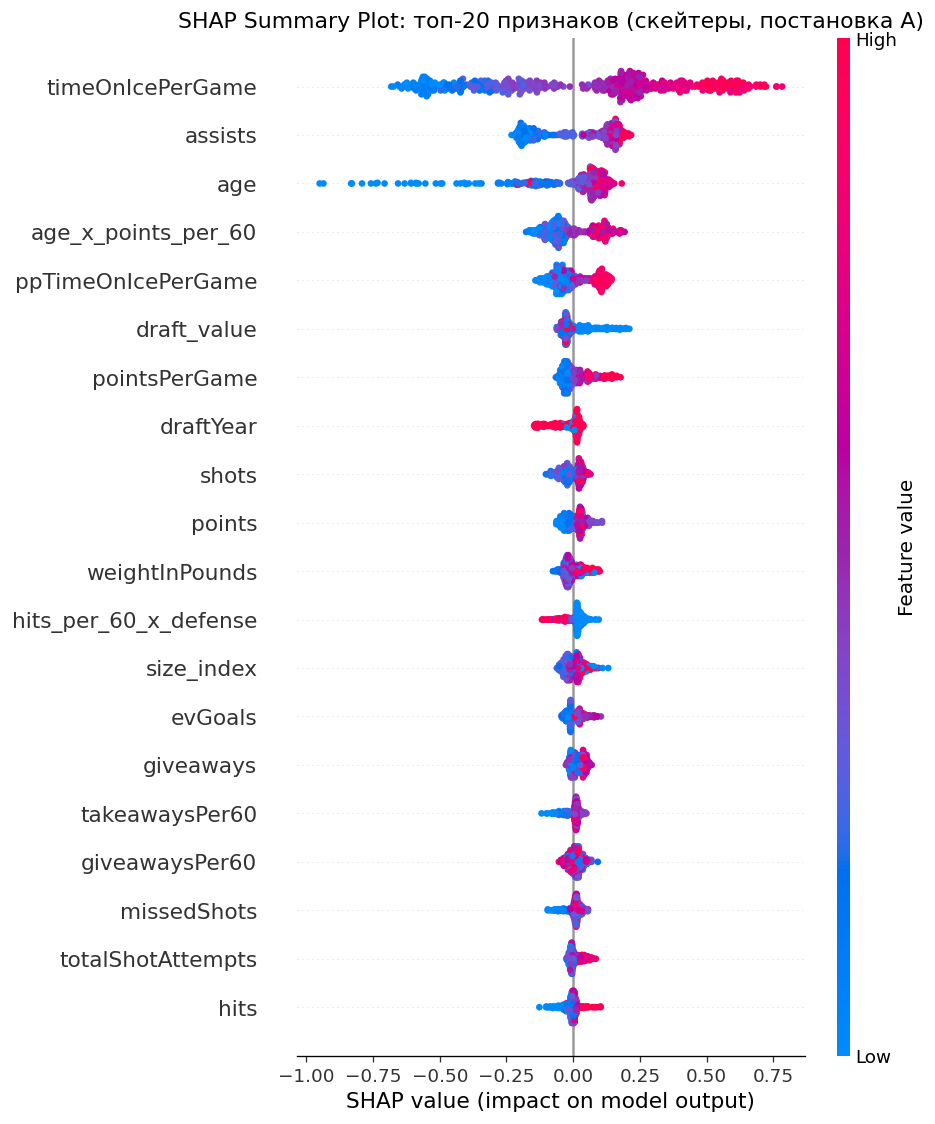

In [10]:
explainer = shap.TreeExplainer(inner_model)
shap_values = explainer.shap_values(x_test_scaled)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    x_test_scaled,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary Plot: топ-20 признаков (скейтеры, постановка А)")
plt.tight_layout()
plt.savefig(images_dir / "shap_summary_skaters.png", bbox_inches="tight")
plt.show()

### Выводы по SHAP summary plot

**Топ-1: `timeOnIcePerGame`** - самый важный признак с большим отрывом.
Высокое время на льду сильно увеличивает предсказанную
зарплату. Это логично т.к. тренер доверяет тем кому платят.

**Топ-2: `assists`** - передачи важнее голов для определения зарплаты.
Это согласуется с хоккейной реальностью т.к. плеймейкеры ценятся высоко,
и передачи это более стабильный показатель чем голы.

**Топ-3: `age`** - интересный паттерн. Синие точки (это молодые игроки) уходят
влево т.е. молодость иногда предсказанную зарплату. Разброс огромный, что
говорит о нелинейности: молодой игрок может получать как мало так и много
в зависимости от статистики.

**Топ-4: `age_x_points_per_60`** - возраст × продуктивность.
Подтверждает что модель научилась комбинировать возраст и результативность т.е.
молодой продуктивный игрок оценивается иначе чем возрастной с той же статистикой.

**Топ-5: `ppTimeOnIcePerGame`** - время в большинстве. Игроки которым доверяют
в большинстве получают значительно больше, это элитный статус в команде.

**`draft_value`** - номер пика на драфте влияет на зарплату даже спустя годы.
Топ-пики традиционно получают контракты с надбавкой за потенциал.

**`hits_per_60_x_defense`** - interaction feature для защитников. Модель
правильно выучила что хиты важны именно для защитников, а не для нападающих.

**Общий вывод:** модель опирается на экономически осмысленные признаки. Физические данные
и `hits`, `giveaways` тоже попали в топ-20 но с меньшим влиянием.

#### Waterfall plots (разбор конкретных игроков)

Выбираем трёх игроков из тест-сета:
- **Точное попадание** - минимальная абсолютная ошибка
- **Переоценённый** - модель сильно завысила зарплату
- **Недооценённый** - модель сильно занизила зарплату

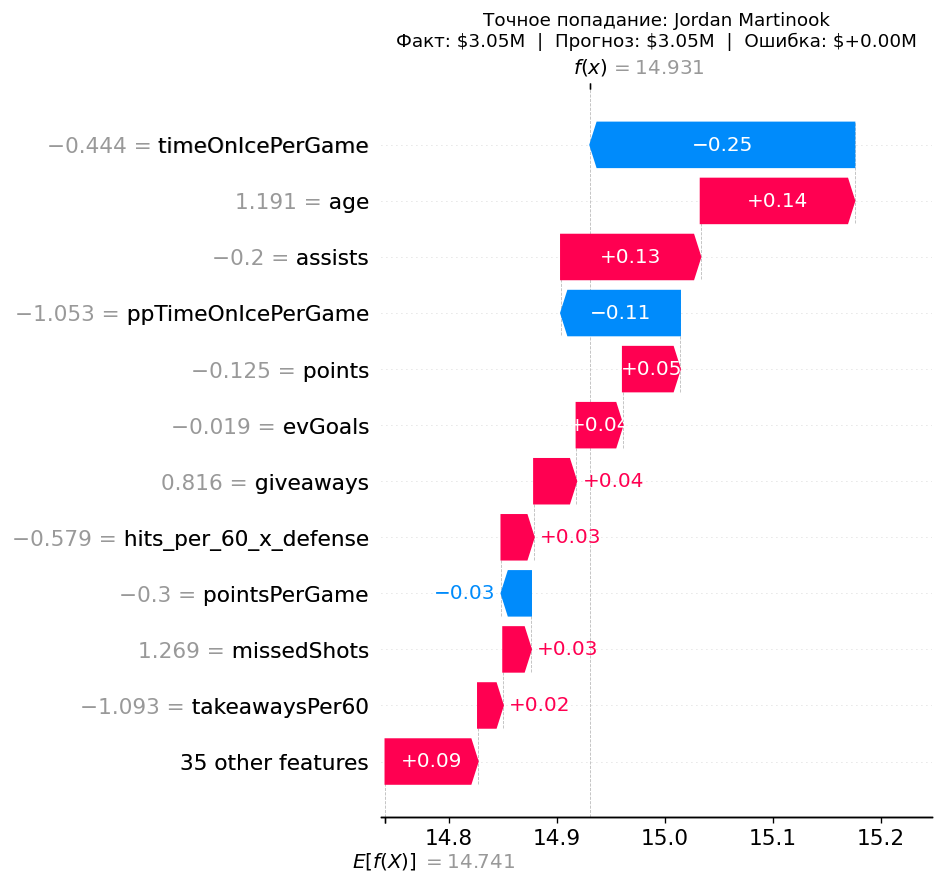

Точное попадание: Jordan Martinook | факт=3.05M | прогноз=3.05M


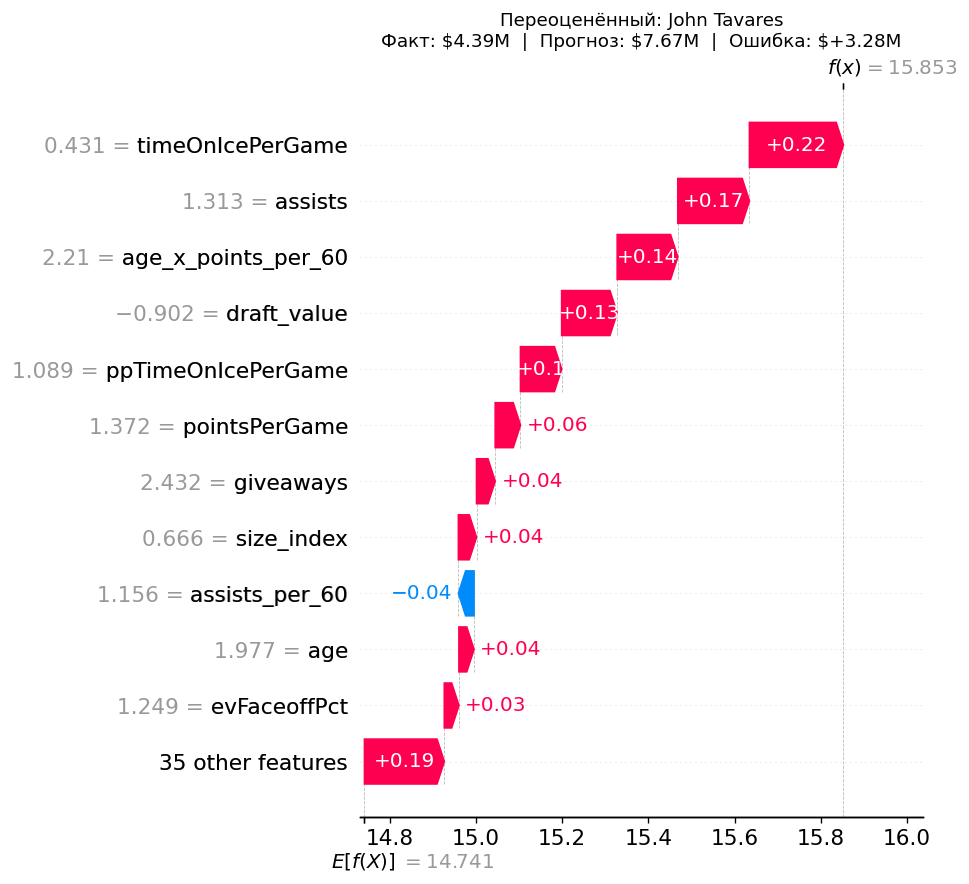

Переоценённый: John Tavares | факт=4.39M | прогноз=7.67M


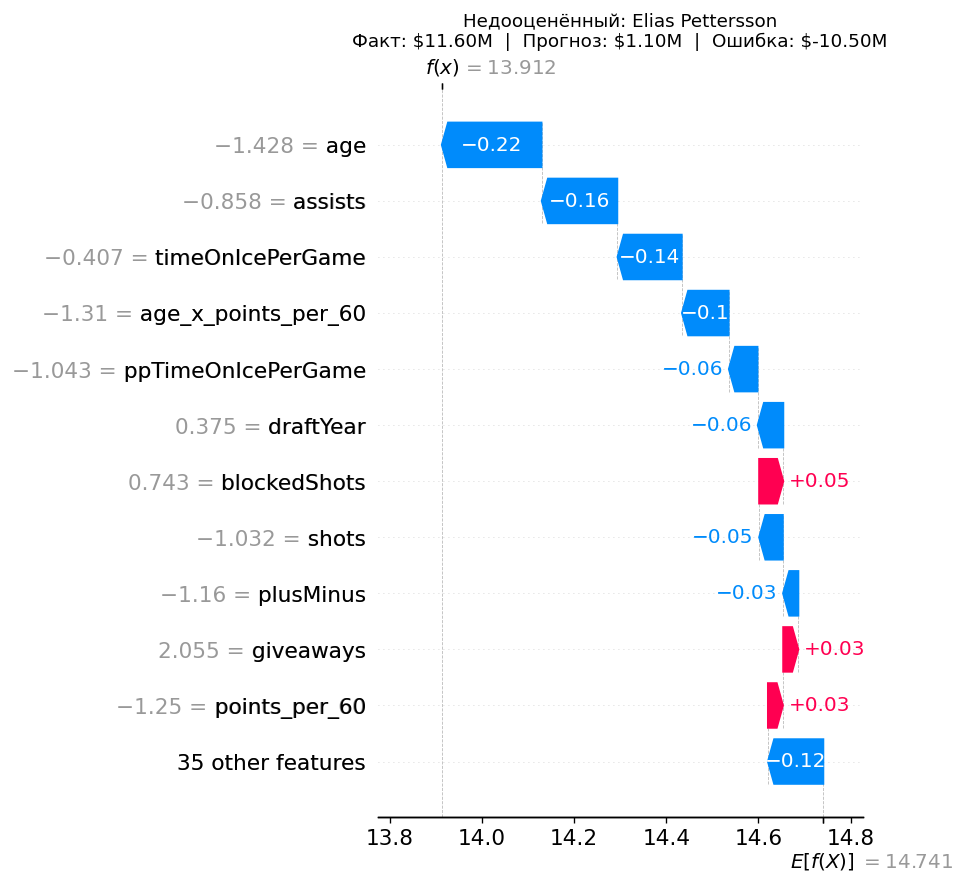

Недооценённый: Elias Pettersson | факт=11.60M | прогноз=1.10M


In [11]:
test = test.copy()
test["pred_cap_hit"] = np.expm1(model.predict(x_test))
test["actual_cap_hit"] = np.expm1(test["log_cap_hit"])
test["error"] = test["pred_cap_hit"] - test["actual_cap_hit"]
idx_accurate = test["error"].abs().idxmin()
idx_over = test["error"].idxmax()
idx_under = test["error"].idxmin()

cases = {
    "accurate": (idx_accurate, "Точное попадание"),
    "overvalued": (idx_over, "Переоценённый"),
    "undervalued": (idx_under, "Недооценённый"),
}

explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=x_test_scaled.values,
    feature_names=selected_cols,
)

for case_name, (idx, title) in cases.items():
    pos = x_test.index.get_loc(idx)
    player = test.loc[idx, "skaterFullName"]
    actual = test.loc[idx, "actual_cap_hit"] / 1e6
    predicted = test.loc[idx, "pred_cap_hit"] / 1e6

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(explanation[pos], max_display=12, show=False)
    plt.title(
        f"{title}: {player}\n"
        f"Факт: ${actual:.2f}M  |  Прогноз: ${predicted:.2f}M  |  "
        f"Ошибка: ${(predicted - actual):+.2f}M",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(
        images_dir / f"shap_waterfall_{case_name}.png",
        bbox_inches="tight",
    )
    plt.show()
    print(f"{title}: {player} | факт={actual:.2f}M | прогноз={predicted:.2f}M")

### Выводы по waterfall plots

**Точное попадание: Jordan Martinook ($3.05M - $3.05M)**

Модель практически идеально предсказала зарплату. Признаки
работают в разные стороны и почти точно компенсируют друг друга:
`timeOnIcePerGame` тянет вниз т.к. у него среднее время на льду
для своей зарплаты, `age` тянет вверх т.к. опытный игрок.
`assists` и `points` добавляют небольшой положительный вклад.
Итог: базовое ожидание модели скорректировалось
до точного попадания. 

**Переоценённый: John Tavares ($4.39M - $7.67M, ошибка +$3.28M)**

Модель завысила зарплату на 75%. Все ключевые признаки
толкают предсказание вверх: высокое время на льду,
много передач, высокий `age_x_points_per_60` т.е.
модель видит опытного продуктивного центра и предсказывает топ-зарплату.
Но этому есть причина, я загуглила эту информацию. Оказывается, Таварес хотел остаться в «Торонто» и был готов взять меньше денег, чтобы это произошло т.е. он сознательно подписал контракт ниже рынка.
Модель не знает о мотивации игрока при подписании и не может предсказать такие контракты, и это нормально.

**Недооценённый: Elias Pettersson ($11.60M - $1.10M, ошибка -$10.50M)**

Сильная недооценка, модель предсказала в 10 раз меньше
реальной зарплаты. Причина видна на графике: все признаки тянут
предсказание вниз. `age` т.к. молодой,
`assists` и `timeOnIcePerGame` тоже отрицательные.

У этого игрока хорошая статистика, но SHAP показывает
отрицательные вклады. Объяснение: в логарифмическом пространстве
это очеь высокое значение далеко за пределами обычного
диапазона обучающей выборки. Модель никогда не видела комбинацию
молодой + такая зарплата и не может правильно экстраполировать.
Суперзвёздные контракты это принципиальное ограничение модели т.к.
их слишком мало в данных для надёжного обучения.

#### Dependence plots (нелинейные зависимости ключевых признаков)

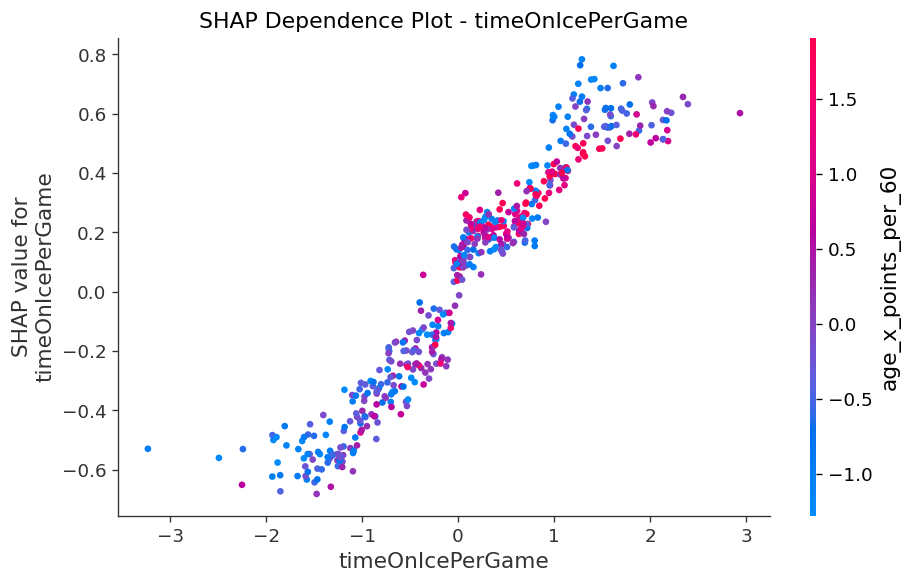

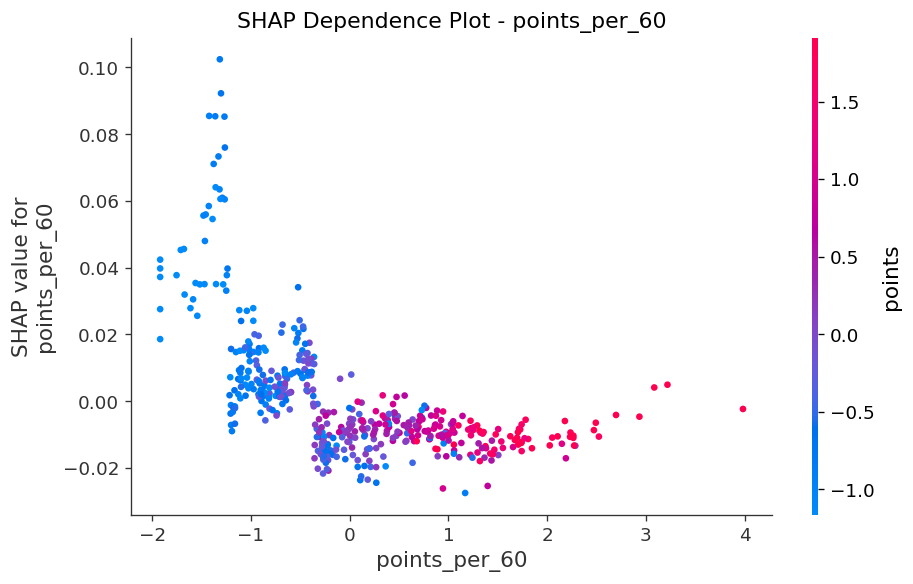

In [13]:
for feature in ["timeOnIcePerGame", "points_per_60"]:

    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        feature,
        shap_values,
        x_test_scaled,
        ax=ax,
        show=False,
    )
    ax.set_title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()
    plt.savefig(
        images_dir / f"shap_dependence_{feature}.png",
        bbox_inches="tight",
    )
    plt.show()

### Выводы по dependence plots

**timeOnIcePerGame (interaction: age_x_points_per_60)**

Зависимость почти идеально линейная т.е. чем больше времени на льду,
тем выше SHAP-вклад и тем выше предсказанная зарплата.
Интересен interaction с `age_x_points_per_60`: при
одинаковом времени на льду розовые точки (т.е. высокий `age_x_points_per_60`)
расположены выше синих. То есть модель учитывает что одинаковое время
на льду у молодого результативного игрока означает более высокую зарплату
чем у возрастного с той же продуктивностью и это логичное поведение.

**points_per_60 (interaction: points)**

Зависимость обратная.
При низких `points_per_60` SHAP-вклад положительный,
при высоких слабо отрицательный или нулевой.
Объяснение: `points_per_60` это метрика эффективности за время на льду,
а не объёма. Игрок с высоким `points_per_60` но низким `points`это игрок с малым льдом который редко выходит
но забивает когда выходит. Таким игрокам модель даёт небольшую надбавку
за эффективность. Но звёзды с большим льдом 
имеют высокие абсолютные `points` и их зарплата объясняется через
`timeOnIcePerGame` и `assists`, а не через `points_per_60`.
Это как раз пример того почему такие модели важнее смотреть
через SHAP чем через корреляции: сырая корреляция `points_per_60` с
зарплатой может быть положительная, но эффект при контроле других
признаков оказывается другим.

### Error analysis (анализ ошибок финальной модели)

Смотрим на паттерны ошибок: где модель систематически ошибается,
по каким игрокам и почему. 

In [14]:
preds = pd.read_csv(models_dir / "skaters_test_predictions.csv")

# ошибки по диапазонам зарплат
bucket_stats = (
    preds.groupby("salary_bucket", observed=True)["abs_error"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "MAE средн.", "median": "MAE медиана", "count": "Игроков"})
)
bucket_stats["MAE средн."] = bucket_stats["MAE средн."].apply(fmt_m)
bucket_stats["MAE медиана"] = bucket_stats["MAE медиана"].apply(fmt_m)
print("Ошибки по диапазонам зарплат:")
display(bucket_stats)

print()

# ошибки по позициям
pos_stats = (
    preds.groupby("positionCode")["abs_error"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "MAE средн.", "median": "MAE медиана", "count": "Игроков"})
)
pos_stats["MAE средн."] = pos_stats["MAE средн."].apply(fmt_m)
pos_stats["MAE медиана"] = pos_stats["MAE медиана"].apply(fmt_m)
print("Ошибки по позициям:")
display(pos_stats)

Ошибки по диапазонам зарплат:


,MAE средн.,MAE медиана,Игроков
salary_bucket,,,
1-3M,$0.60M,$0.47M,74
3-7M,$1.47M,$1.30M,195
<1M,$0.38M,$0.19M,100
>7M,$2.10M,$1.73M,107



Ошибки по позициям:


,MAE средн.,MAE медиана,Игроков
positionCode,,,
C,$1.27M,$0.89M,166
D,$1.35M,$1.06M,164
L,$1.12M,$0.65M,76
R,$1.10M,$0.70M,70


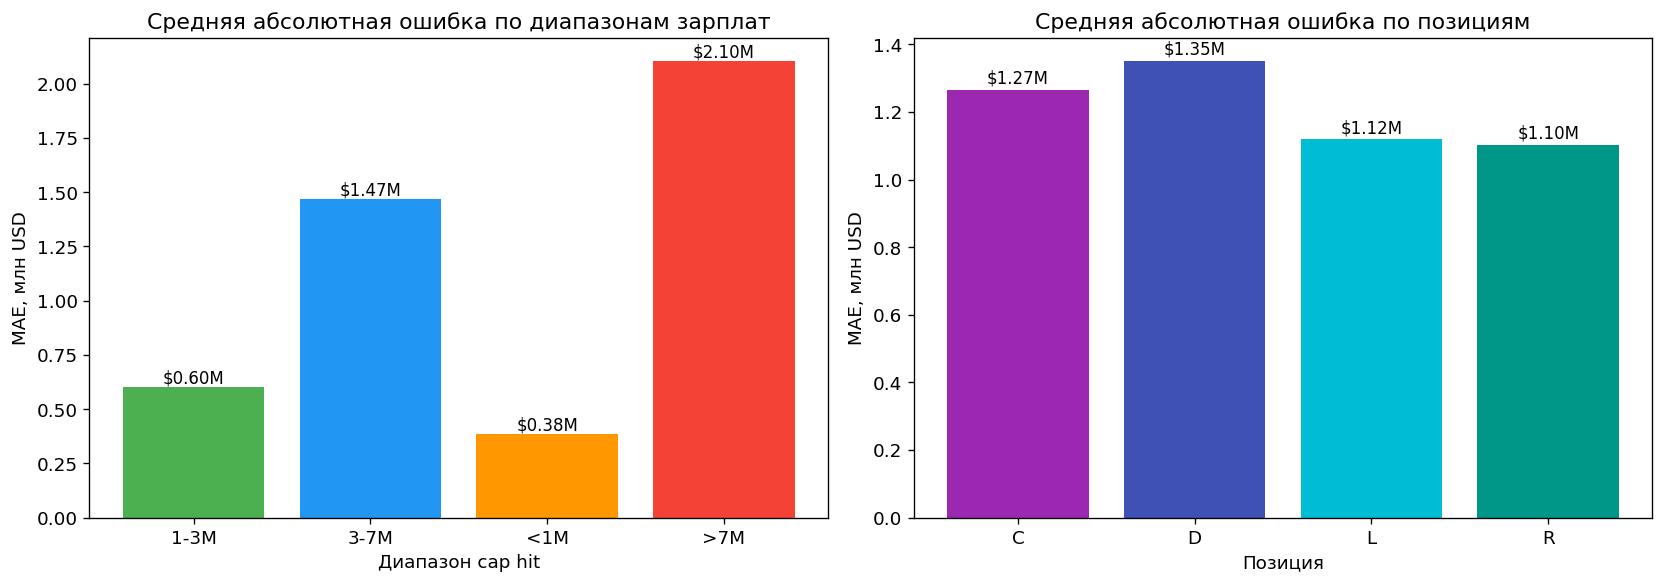

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# по диапазонам зарплат
bucket_raw = (
    preds.groupby("salary_bucket", observed=True)["abs_error"]
    .mean()
    / 1e6
)
axes[0].bar(bucket_raw.index, bucket_raw.values, color=["#4CAF50", "#2196F3", "#FF9800", "#F44336"])
axes[0].set_title("Средняя абсолютная ошибка по диапазонам зарплат")
axes[0].set_xlabel("Диапазон cap hit")
axes[0].set_ylabel("MAE, млн USD")
for i, v in enumerate(bucket_raw.values):
    axes[0].text(i, v + 0.02, f"${v:.2f}M", ha="center", fontsize=10)

# по позициям
pos_raw = (
    preds.groupby("positionCode")["abs_error"]
    .mean()
    / 1e6
)
axes[1].bar(pos_raw.index, pos_raw.values, color=["#9C27B0", "#3F51B5", "#00BCD4", "#009688"])
axes[1].set_title("Средняя абсолютная ошибка по позициям")
axes[1].set_xlabel("Позиция")
axes[1].set_ylabel("MAE, млн USD")
for i, v in enumerate(pos_raw.values):
    axes[1].text(i, v + 0.02, f"${v:.2f}M", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(images_dir / "error_analysis_skaters.png", bbox_inches="tight")
plt.show()

In [16]:
name_col = "skaterFullName"

print("Топ-10 переоценённых:")
over = preds.nlargest(10, "error")[
    [name_col, "actual_cap_hit", "pred_cap_hit", "error", "pct_error"]
].copy()
over["actual_cap_hit"] = over["actual_cap_hit"].apply(fmt_m)
over["pred_cap_hit"] = over["pred_cap_hit"].apply(fmt_m)
over["error"] = over["error"].apply(lambda x: f"+{fmt_m(x)}")
over["pct_error"] = over["pct_error"].apply(lambda x: f"+{x:.1f}%")
over.columns = ["Игрок", "Факт", "Прогноз", "Ошибка", "Ошибка %"]
display(over.reset_index(drop=True))

print()
print("Топ-10 недооценённых:")
under = preds.nsmallest(10, "error")[
    [name_col, "actual_cap_hit", "pred_cap_hit", "error", "pct_error"]
].copy()
under["actual_cap_hit"] = under["actual_cap_hit"].apply(fmt_m)
under["pred_cap_hit"] = under["pred_cap_hit"].apply(fmt_m)
under["error"] = under["error"].apply(lambda x: fmt_m(x))
under["pct_error"] = under["pct_error"].apply(lambda x: f"{x:.1f}%")
under.columns = ["Игрок", "Факт", "Прогноз", "Ошибка", "Ошибка %"]
display(under.reset_index(drop=True))

Топ-10 переоценённых:


,Игрок,Факт,Прогноз,Ошибка,Ошибка %
0,John Tavares,$4.39M,$7.67M,+$3.28M,+74.7%
1,Kirill Marchenko,$3.85M,$6.59M,+$2.74M,+71.1%
2,Sean Walker,$3.60M,$5.98M,+$2.38M,+66.2%
3,Aaron Ekblad,$6.10M,$8.44M,+$2.34M,+38.4%
4,Jack Hughes,$8.00M,$10.30M,+$2.30M,+28.8%
5,Parker Wotherspoon,$1.00M,$3.24M,+$2.24M,+224.0%
6,Macklin Celebrini,$0.97M,$3.20M,+$2.23M,+228.4%
7,Ryan O'Reilly,$4.50M,$6.64M,+$2.14M,+47.7%
8,Jimmy Snuggerud,$0.95M,$3.02M,+$2.07M,+217.9%
9,Shayne Gostisbehere,$3.20M,$5.12M,+$1.92M,+60.0%



Топ-10 недооценённых:


,Игрок,Факт,Прогноз,Ошибка,Ошибка %
0,Elias Pettersson,$11.60M,$1.10M,$-10.50M,-90.5%
1,Kirill Kaprizov,$17.00M,$9.07M,$-7.93M,-46.6%
2,Logan Cooley,$10.00M,$3.93M,$-6.07M,-60.7%
3,Elias Pettersson,$11.60M,$5.80M,$-5.80M,-50.0%
4,Tyler Seguin,$9.85M,$4.13M,$-5.72M,-58.1%
5,Josh Norris,$7.95M,$2.76M,$-5.19M,-65.3%
6,Thomas Harley,$10.59M,$5.45M,$-5.13M,-48.5%
7,Ondrej Palat,$6.00M,$1.39M,$-4.61M,-76.8%
8,Leon Draisaitl,$14.00M,$9.55M,$-4.45M,-31.8%
9,Brayden Point,$9.50M,$5.10M,$-4.40M,-46.3%


### Выводы по error analysis

По диапазонам зарплат: ошибка растёт с зарплатой:

Дешёвые игроки (<1M) предсказываются очень точно, медианная ошибка
всего $190K. Модель хорошо различает дешёвых игроков,
т.к. их много в обучающей выборке. Средний сегмент (1-3M) тоже неплохо, $470K медиана.
Резкий скачок начинается с $3M: в зоне 3-7M ошибка вырастает
до $1.47M, игроков этого диапазона меньше и их зарплаты сильно зависят от контекста. Топ-контракты (>7M) предсказываются хуже всего, MAE $2.10M,
что составляет 20-30% от самой зарплаты, таких игроков вообще мало.

По позициям: для защитников сложнее всего:

Защитники (D) имеют наибольшую ошибку ($1.35M среднее, $1.06M медиана). Причина: ценность защитника сложнее выразить через
стандартную статистику т.к. важны позиционная игра, надёжность в зоне и командный контекст, которых в данных нет.
Разрыв между средней и медианной ошибкой у центров (C) указывает на несколько крупных промахов которые тянут среднее вверх
(например Tavares, о котором мы говорили ранее). Крылья (L, R) предсказываются лучше всего.

Паттерны переоценки:

Есть два типа ошибок в этом плане. Первый тип это ветераны на дисконтных контрактах: Tavares,
O'Reilly, Gostisbehere. Они играют хорошо но подписали контракты ниже рынка. Второй тип это молодые игроки на дебютных контрактах: Celebrini, Snuggerud, Wotherspoon. Их зарплата ограничена правилами RFA и entry-level контрактами,
но статистика уже на уровне игроков за $3-4M. Модель справедливо оценивает их по игре, но не знает
об ограничениях NHL на зарплату молодых игроков.

Паттерны недооценки:

Elias Pettersson появляется дважды и это признак
дублирующейся записи в тест-сете, которая не была отловлена при очистке
(возможно трейд в середине сезона создал две строки для одного игрока).
Оба предсказания занижены, что подтверждает проблему с
его контрактом, он находится за пределами типичного
диапазона обучающей выборки. Kaprizov
и Draisaitl — у них тоже контракты за пределами
типичного диапазона. Все топ-10 недооценённых
имеют зарплату выше $6M, что подтверждает проблему
с предсказанием топ-контрактов.

## Вратари: постановка А

Для вратарей используется кросс-валидация по сезонам вместо фиксированного
val/test сплита. Причина: у нас всего 286 игроков за 5 сезонов и фиксированный
тест слишком мал для надёжной оценки. Кросс-валидация по сезонам
даёт 4 фолда с нарастающим train: 2022->2023, 2022-23->2024, 2022-24->2025,
2022-25->2026. Метрики усредняются по всем фолдам.

In [3]:
cv_A = pd.read_csv(models_dir / "goalies_A_cv_results.csv")

cv_display = cv_A.copy()
cv_display["mae"] = cv_display["mae"].apply(fmt_m)
cv_display["mae_std"] = cv_display["mae_std"].apply(lambda x: fmt_m(x))
cv_display["rmse"] = cv_display["rmse"].apply(fmt_m)
cv_display["r2"] = cv_display["r2"].round(3)
cv_display["mape"] = cv_display["mape"].round(1).astype(str) + "%"
cv_display["label"] = cv_display["label"].str.replace("goalies_A_", "").str.replace("_CV", "")
cv_display = cv_display.rename(columns={
    "label": "Модель",
    "mae": "MAE (среднее)",
    "mae_std": "MAE (std)",
    "rmse": "RMSE",
    "r2": "R²",
    "mape": "MAPE",
})
display(cv_display[["Модель", "MAE (среднее)", "MAE (std)", "RMSE", "R²", "MAPE"]])

,Модель,MAE (среднее),MAE (std),RMSE,R²,MAPE
0,ridge,$1.58M,$0.15M,$2.18M,0.159,52.5%
1,elasticnet,$2.12M,$0.36M,$2.75M,-0.209,75.8%
2,random_forest,$1.35M,$0.18M,$1.81M,0.473,46.1%
3,xgboost,$1.31M,$0.16M,$1.74M,0.510,45.0%
4,lightgbm,$1.38M,$0.16M,$1.85M,0.451,49.1%
5,catboost,$1.25M,$0.14M,$1.70M,0.529,43.7%
6,lightgbm_tuned,$1.35M,$0.11M,$1.86M,0.433,47.0%
7,xgboost_tuned,$1.26M,$0.13M,$1.72M,0.516,44.0%
8,catboost_tuned,$1.26M,$0.14M,$1.72M,0.521,43.5%
9,random_forest_tuned,$1.36M,$0.20M,$1.81M,0.471,46.1%


### Выводы по вратарям постановки А

Лучшая модель: CatBoost, MAE=$1.251M±$0.136M, MAPE=43.7%, R2=0.529

Линейные модели не справляются с задачей. Ridge
очень плохо объясняет дисперсию зарплат. ElasticNet после тюнинга ещё хуже т.к.
на маленькой выборке вратарей линейные модели не улавливают
нелинейные зависимости между статистикой и зарплатой.

Бустинг работает значительно лучше. CatBoost дефолтный показал лучший
результат и при этом наиболее стабильный std среди
всех моделей т.е. разброс между фолдами минимальный. XGBoost tuned 
и CatBoost tuned практически не отличаются от дефолтного CatBoost.

Тюнинг не помог. Лучшие дефолтные модели оказались сопоставимы или лучше
tuned версий. На 286 строках Optuna переподбирает параметры под конкретный
фолд а не под задачу в целом.

Stacking хуже базовых моделей. На 286 строках с cv=3
ансамбль не даёт преимущества т.к. базовые модели недостаточно разнообразны.

**Сравнение со скейтерами.** MAPE вратарей 43.7% против 31.5% у скейтеров и это
заметно хуже. Причины: меньше данных, статистика вратаря сильнее зависит
от командного контекста.

**Итоговый выбор: CatBoost, CV MAE=$1.251M, MAPE=43.7%, R2=0.529.**

#### SHAP для вратарей

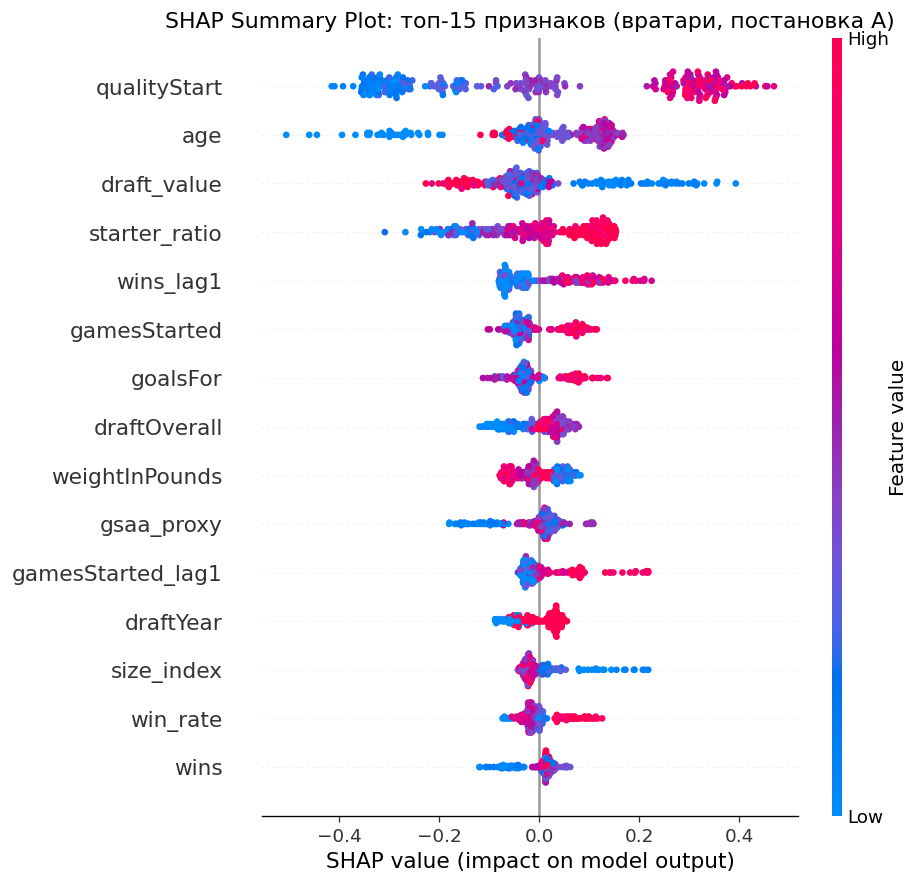

In [6]:
model_go = joblib.load(models_dir / "goalies_A_xgboost_tuned.joblib")

full_go = pd.concat([
    pd.read_csv(features_dir / "goalies_train.csv"),
    pd.read_csv(features_dir / "goalies_val.csv"),
    pd.read_csv(features_dir / "goalies_test.csv"),
], ignore_index=True)

feature_cols_go = get_feature_cols(full_go, prefix="goalies_A")
x_go = full_go[feature_cols_go]

scaler_go = model_go.named_steps["scaler"]
inner_go = model_go.named_steps["model"]
x_go_scaled = pd.DataFrame(
    scaler_go.transform(x_go),
    columns=feature_cols_go,
)

explainer_go = shap.TreeExplainer(inner_go)
shap_values_go = explainer_go.shap_values(x_go_scaled)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_go,
    x_go_scaled,
    max_display=15,
    show=False,
)
plt.title("SHAP Summary Plot: топ-15 признаков (вратари, постановка А)")
plt.tight_layout()
plt.savefig(images_dir / "shap_summary_goalies.png", bbox_inches="tight")
plt.show()

### Выводы по SHAP вратарей

**Топ-1: `qualityStart`** - качественные старты (матчи где sv% выше среднего)
доминируют над остальными признаками. Высокое значение
сильно увеличивает предсказанную зарплату. Это логично т.к.
qualityStart напрямую отражает стабильность вратаря а именно за неё
команды и платят больше всего.

**Топ-2: `age`** - нелинейная зависимость. Синие точки (молодые вратари)
уходят влево т.е. молодость снижает предсказание. Пик зарплаты приходится
на средний возраст, после чего начинается снижение. Но важна комбинация с другими признаками.

**Топ-3: `draft_value`** - как и у скейтеров, топ-пики получают надбавку
даже спустя годы после драфта. 

**Топ-4: `starter_ratio`** - доля стартов от общего числа игр.
Основной вратарь команды получает значительно больше запасного.

**Топ-5: `wins_lag1`** - победы прошлого сезона. Лаговый признак
показывает что репутация по результатам прошлого сезона влияет на
текущий контракт. Это логично т.к. переговоры по контракту часто опираются
на то что вратарь показал в предыдущем году.

**`gsaa_proxy`** попал в топ-15 но с небольшим вкладом. Его информация частично поглощается `qualityStart` с которым
он коррелирует.

**`gamesStarted_lag1`** - объём игры прошлого сезона влияет на зарплату
текущего. Вместе с `wins_lag1` подтверждает что лаговые игровые признаки несут полезный сигнал о репутации вратаря.

**Общий вывод:** модель вратарей тоже опирается на осмысленные признаки. У вратарей нет прям одного доминирующего признака,
зарплата определяется комбинацией факторов.

### Error analysis вратарей постановки А

Поскольку для вратарей используется кросс-валидация по сезонам,
а не фиксированный тест-сет, полный error analysis с конкретными
игроками недоступен. Вместо этого смотрим на стабильность метрик
по фолдам финальной модели (CatBoost).

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

full_go = pd.concat([
    pd.read_csv(features_dir / "goalies_train.csv"),
    pd.read_csv(features_dir / "goalies_val.csv"),
    pd.read_csv(features_dir / "goalies_test.csv"),
], ignore_index=True)

feature_cols_go = get_feature_cols(full_go, prefix="goalies_A")
seasons = sorted(full_go["season_year"].unique())

fold_results = []
for i in range(1, len(seasons)):
    train_seasons = seasons[:i]
    val_season = seasons[i]
    train_idx = full_go[full_go["season_year"].isin(train_seasons)].index
    val_idx = full_go[full_go["season_year"] == val_season].index

    x_tr = full_go.loc[train_idx, feature_cols_go]
    y_tr = full_go.loc[train_idx, "log_cap_hit"]
    x_v = full_go.loc[val_idx, feature_cols_go]
    y_v = full_go.loc[val_idx, "log_cap_hit"]

    pipeline_fold = Pipeline([
        ("scaler", StandardScaler()),
        ("model", CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_state=42,
            verbose=0,
        )),
    ])
    pipeline_fold.fit(x_tr, y_tr)

    pred = np.expm1(pipeline_fold.predict(x_v))
    actual = np.expm1(y_v.values)
    mae = np.mean(np.abs(actual - pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    fold_results.append({
        "Фолд": f"train {list(train_seasons)} -> val [{val_season}]",
        "Игроков в val": len(val_idx),
        "MAE": fmt_m(mae),
        "MAPE": f"{mape:.1f}%",
    })

display(pd.DataFrame(fold_results))

,Фолд,Игроков в val,MAE,MAPE
0,train [np.int64(2022)] -> val [2023],57,$1.07M,48.6%
1,"train [np.int64(2022), np.int64(2023)] -> val ...",62,$1.19M,51.8%
2,"train [np.int64(2022), np.int64(2023), np.int6...",60,$1.32M,43.1%
3,"train [np.int64(2022), np.int64(2023), np.int6...",51,$1.43M,31.4%


### Выводы по фолдам вратарей

MAE растёт с каждым фолдом несмотря на
то что train становится больше. Это объясняется инфляцией контрактов,
сезоны 2025-2026 имеют более высокий потолок, и зарплаты
выросли. Модель обученная на исторических данных недооценивает новые
контракты.

MAPE ведёт себя обратно: падает с 51.8% до 31.4% к последнему
фолду. Это говорит о том что относительные ошибки уменьшаются и модель
лучше понимает структуру зарплат по мере накопления данных, даже если
абсолютные ошибки растут из-за инфляции контрактов.

Общий вывод: нестабильность по фолдам ожидаема при 51-62 вратарях. Для надёжной оценки вратарей нужно больше сезонов
или дополнительные источники данных.

## Постановка Б: предсказание будущего контракта

### Описание постановки

В постановке Б таргет сдвинут на один сезон вперёд: модель видит
статистику игрока за сезон N и предсказывает cap hit сезона N+1.
В выборку попадают только игроки у которых зарплата изменилась
более чем на 5%, то есть был подписан новый контракт.

Из 2906 скейтеров постановки А осталось 586 со сменой контракта.
Train: 362 игрока (сезоны 2022-2023), val: 172 (2024), test: 52 (2025).

### Важное замечание про первую попытку

В первой версии постановки Б в признаки входили `cap_hit_lag1`
(текущая зарплата игрока) и `cap_hit_delta` (изменение зарплаты
относительно прошлого сезона). Модели показывали вообще нереальный
MAE на val: Random Forest $49K, XGBoost tuned $88K, MAPE примерно 1%.

Причина: модель не предсказывала будущую зарплату по статистике,
она просто выучила что следующая зарплата близка к текущей.
`cap_hit_lag1` это почти тот же таргет, только за прошлый год.
Для игроков у которых контракт изменился на 5-15% достаточно знать
текущую зарплату и добавить небольшое изменение.

Это информационный leakage, т.е. признак слишком прямо намекал на таргет.
После исключения `cap_hit_lag1`, `cap_hit_delta` и `cap_hit_next`
из признаков результаты стали реалистичными и сопоставимыми
с постановкой А.

### Таблица экспериментов постановки Б (скейтеры)

In [10]:
exp_B = pd.read_csv(models_dir / "skaters_B_experiments.csv")
display(highlight_best(exp_B))

,label,mae,rmse,r2,mape
0,skaters_B_baseline_linear,$1.575M,$2.261M,0.231,50.4%
1,skaters_B_ridge,$1.490M,$2.137M,0.313,50.5%
2,skaters_B_elasticnet,$2.071M,$2.865M,-0.235,66.2%
3,skaters_B_random_forest,$1.438M,$1.888M,0.464,46.3%
4,skaters_B_xgboost,$1.396M,$1.861M,0.479,44.2%
5,skaters_B_lightgbm,$1.289M,$1.721M,0.554,43.5%
6,skaters_B_catboost,$1.331M,$1.730M,0.549,44.2%
7,skaters_B_lightgbm_tuned,$1.228M,$1.645M,0.593,43.4%
8,skaters_B_xgboost_tuned,$1.251M,$1.671M,0.580,42.9%
9,skaters_B_catboost_tuned,$1.256M,$1.675M,0.578,42.7%


### Выводы по таблице экспериментов (постановка Б, скейтеры)

Общая картина схожа с постановкой А, бустинг лучше линейных моделей,
ElasticNet дефолтный провалился, PCA худший
по R2.

Baseline (LinearRegression) показал MAE=$1.575M, это хуже чем
в постановке А. Это ожидаемо т.к. меньше данных, предсказывать контракт на год вперёд труднее
чем текущий.

Ridge лучше baseline, мультиколлинеарность в данных есть и регуляризация помогает даже на маленькой выборке.

LightGBM tuned лучший по val.
Разница между топ-3 минимальная.

SelectFromModel незначительно хуже
лучшей модели но при вдвое меньшем числе признаков, это хороший trade-off
для интерпретируемости.

Stacking хуже лучших одиночных моделей. На 362 строках
ансамбль не даёт преимущества.

R2 у лучших моделей 0.57-0.59 против 0.70 в постановке А, т.е.
постановка Б объясняет меньше дисперсии при сопоставимых абсолютных
ошибках. Предсказание будущего контракта объективно сложнее.

### Финальная оценка на тест-сете (постановка Б, скейтеры)

In [11]:
test_B = pd.read_csv(models_dir / "skaters_B_test_results.csv")

result_rows_B = []
for _, row in test_B.iterrows():
    pct = row["delta_mae"] / row["val_mae"] * 100
    result_rows_B.append({
        "Модель": row["label"].replace("skaters_B_", "").replace("_TEST", ""),
        "Val MAE": fmt_m(row["val_mae"]),
        "Test MAE": fmt_m(row["mae"]),
        "Разрыв": f"+{pct:.1f}%",
        "Test MAPE": f"{row['mape']:.1f}%",
        "Test R²": round(row["r2"], 3),
    })

display(pd.DataFrame(result_rows_B))

,Модель,Val MAE,Test MAE,Разрыв,Test MAPE,Test R²
0,lightgbm_tuned,$1.23M,$2.24M,+82.6%,39.6%,0.306
1,xgboost_tuned,$1.25M,$2.29M,+83.1%,40.0%,0.265
2,catboost_tuned,$1.26M,$2.30M,+83.0%,40.8%,0.258


### Выводы: val vs test разрыв постановки Б

Val-test разрыв у всех трёх моделей составил около 83%. Причина не в модели а в данных, их слишком мало для надёжной обобщаемости. 
Test R2 у лучшей модели 0.306, модель объясняет только 30% дисперсии
будущих контрактов. Для сравнения постановка А даёт R2=0.667 на тесте.

Дополнительная сложность постановки Б: модель должна предсказать
не просто зарплату по статистике, но и учесть рыночный спрос на игрока
в конкретное межсезонье.

**Итог: постановка Б уступает постановке А по всем критериям.**
Постановка Б не подойдет нам для деплоя.

### Вратари постановки Б

Для вратарей постановки Б выборка составила 73 игрока (39 train,
25 val, 9 test), это слишком мало для обучения.

In [12]:
cv_B = pd.read_csv(models_dir / "goalies_B_cv_results.csv")

cv_display_B = cv_B.copy()
cv_display_B["mae"] = cv_display_B["mae"].apply(fmt_m)
cv_display_B["rmse"] = cv_display_B["rmse"].apply(fmt_m)
cv_display_B["r2"] = cv_display_B["r2"].round(3)
cv_display_B["mape"] = cv_display_B["mape"].round(1).astype(str) + "%"
cv_display_B["label"] = cv_display_B["label"].str.replace("goalies_B_", "").str.replace("_CV", "")
cv_display_B = cv_display_B.rename(columns={
    "label": "Модель",
    "mae": "MAE (среднее)",
    "rmse": "RMSE",
    "r2": "R²",
    "mape": "MAPE",
})
display(cv_display_B[["Модель", "MAE (среднее)", "RMSE", "R²", "MAPE"]])

,Модель,MAE (среднее),RMSE,R²,MAPE
0,ridge,$2.59M,$3.34M,-0.780,85.2%
1,elasticnet,$2.29M,$3.03M,-0.500,61.0%
2,random_forest,$2.11M,$2.79M,-0.264,55.8%
3,xgboost,$2.20M,$3.06M,-0.550,55.1%
4,lightgbm,$2.08M,$2.81M,-0.256,59.9%
5,catboost,$2.14M,$2.86M,-0.336,54.6%
6,lightgbm_tuned,$1.81M,$2.59M,-0.072,52.5%
7,xgboost_tuned,$2.03M,$2.64M,-0.135,59.3%
8,catboost_tuned,$2.19M,$2.95M,-0.395,54.8%
9,random_forest_tuned,$2.06M,$2.74M,-0.209,56.4%


### Выводы по вратарям постановки Б

Все модели без исключения показывают отрицательный R2. Даже лучшая модель
LightGBM tuned едва приближается к нулю. Для сравнения: вратари постановки А дали R2=0.529 у лучшей модели.
Переход к предсказанию будущего контракта на выборке 73 игрока
полностью не имеет смысла. 73 игрока за 3 фолда это критически мало.
Первый фолд имеет только 18 игроков в train, любой алгоритм
будет работать хуже медианного предсказания. Отрицательный R2
у всех дефолтных моделей подтверждает что на таком объёме данных
обучение невозможно в принципе.

**Вывод: goalies_B исключается из дальнейшего рассмотрения.**
Постановка Б для вратарей невозможна при текущем объёме данных.
Для корректного решения этой задачи нужно минимум 10 сезонов данных
вместо 5, или объединение с дополнительными источниками информации
о переговорах по контрактам.

## Сравнение постановок А и Б и выбор финальной модели

## Обоснование выбора финальной модели

### Скейтеры, финальная модель постановки А:

**LightGBM + SelectFromModel (46 признаков)**
Test MAE=$1.247M, MAPE=31.5%, R2=0.667

XGBoost tuned занял первое место по val но на тест-сете
уступил. Val-test разрыв у XGBoost 21.0% против
15.5%, т.е. модель хуже обобщается на новые данные. Отбор 46 признаков
из 91 убрал шумовые признаки которые помогали на val но мешали на тесте. У Stacking test MAE=$1.274M, лучше XGBoost но хуже SelectFromModel. При этом
значительно сложнее, время обучения в 5 раз больше, сложнее деплоить. Прирост качества не оправдывает
сложность.

**Почему не постановка Б?**
Val-test разрыв 82.6% и test R2=0.306 показывают что модель не
обобщается. При 362 обучающих примерах постановка Б
не даёт надёжный результат.

---

### Вратари, финальная модель постановки А:

**CatBoost дефолтный**
CV MAE=$1.251M, MAPE=43.7%, R2=0.529

CatBoost выбран за лучший средний MAE по кросс-валидации и минимальный
std среди всех моделей, это наиболее стабильный результат
на маленькой выборке. XGBoost tuned уступает по R2.

Посановка Б невозможна, R2 отрицательный у всех моделей,
73 игрока недостаточно для обучения.

---

### Ограничения финальных моделей

Модели систематически ошибаются в двух случаях:

**Переоценка**: модель оценивает по статистике но не знает об ограничениях NHL для молодых игроков и личных решениях игроков.

**Недооценка**: суперзвёзды с контрактами >$10M. Таких игроков мало и модель
не может надёжно эпредсказать этот диапазон.

Для улучшения результата необходимы дополнительные данные: статус
агента (UFA/RFA), количество лет до конца контракта и рыночный контекст
межсезонья.

## Визуализация ошибок финальной модели

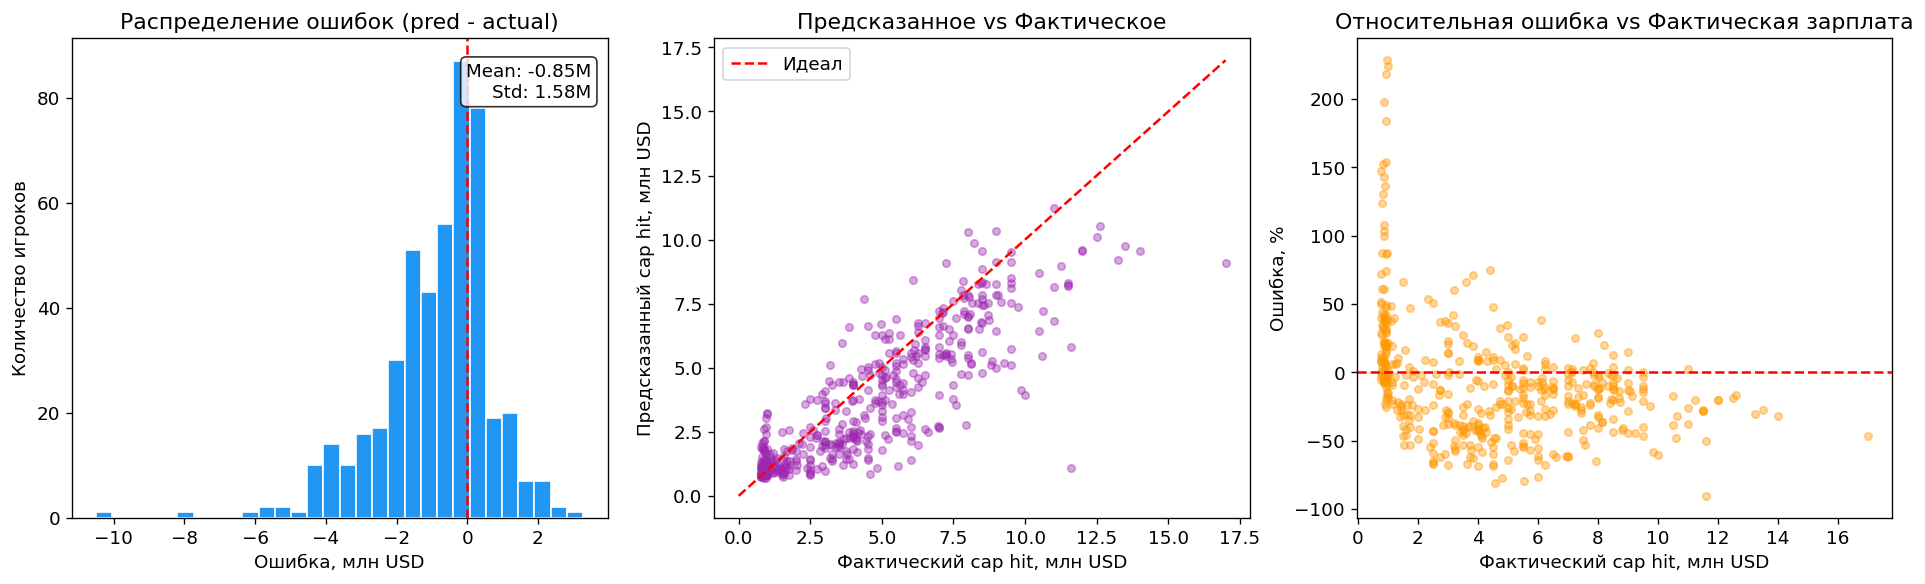

In [14]:
preds = pd.read_csv(models_dir / "skaters_test_predictions.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# гистограмма остатков
axes[0].hist(preds["error"] / 1e6, bins=30, color="#2196F3", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Распределение ошибок (pred - actual)")
axes[0].set_xlabel("Ошибка, млн USD")
axes[0].set_ylabel("Количество игроков")
axes[0].text(
    0.97, 0.95,
    f"Mean: {preds['error'].mean()/1e6:+.2f}M\nStd: {preds['error'].std()/1e6:.2f}M",
    transform=axes[0].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

# предсказанное vs фактическое
axes[1].scatter(
    preds["actual_cap_hit"] / 1e6,
    preds["pred_cap_hit"] / 1e6,
    alpha=0.4, color="#9C27B0", s=20,
)
max_val = max(preds["actual_cap_hit"].max(), preds["pred_cap_hit"].max()) / 1e6
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Идеал")
axes[1].set_title("Предсказанное vs Фактическое")
axes[1].set_xlabel("Фактический cap hit, млн USD")
axes[1].set_ylabel("Предсказанный cap hit, млн USD")
axes[1].legend()

# ошибка vs фактическая зарплата
axes[2].scatter(
    preds["actual_cap_hit"] / 1e6,
    preds["pct_error"],
    alpha=0.4, color="#FF9800", s=20,
)
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_title("Относительная ошибка vs Фактическая зарплата")
axes[2].set_xlabel("Фактический cap hit, млн USD")
axes[2].set_ylabel("Ошибка, %")

plt.tight_layout()
plt.savefig(images_dir / "error_distribution_skaters.png", bbox_inches="tight")
plt.show()

### Выводы по визуализациям ошибок

Распределение остатков имеет выраженный левый хвост, модель в среднем занижает зарплаты.
Это объясняется суперзвёздами в тест-сете, которые создают крупные отрицательные остатки. Медиана при этом близка
к нулю, для большинства игроков модель не смещена.

Предсказанное vs фактическое показывает хорошую линейную зависимость
в диапазоне $0-8M. Выше $8M облако расходится т.к. модель занижает топ-контракты.
Один сильно заметный выброс справа $17M который модель предсказала как примерно $9M.

Относительная ошибка vs зарплата: В диапазоне $2-10M ошибки хаотичны вокруг нуля без явного тренда. Левый кластер (<$1.5M): огромный разброс вверх это молодые игроки на entry-level контрактах которых модель сильно переоценивает относительно их реальной зарплаты. Правый хвост (>$8M): почти все точки в отрицательной зоне, систематическое занижение суперзвёздных контрактов.

## Итог

В рамках проекта решена задача регрессии, предсказание годового
cap hit хоккеиста NHL по игровой статистике и биографическим данным.

Данные собраны самостоятельно через парсинг NHL Stats API,
NHL Web API и Spotrac: 4748 строк × 90 колонок для скейтеров,
525 × 46 для вратарей, сезоны 2021-22 - 2025-26.

Две постановки задачи: предсказание текущего контракта (А)
и будущего контракта (Б), постановка А значительно
стабильнее.

Обучено 15 конфигураций моделей для каждой постановки: от
LinearRegression до Stacking ансамбля. Бустинг превосходит линейные
модели, тюнинг через Optuna дал умеренный прирост, Stacking не
оправдал сложности.

**Финальные модели:**
- Скейтеры: LightGBM + SelectFromModel (46 признаков)
- Вратари: CatBoost

**Ключевые признаки** по SHAP: время на льду,
передачи, возраст, время в большинстве. Для вратарей:
качественные старты, статус в команде.

**Основное ограничение:** модель не предсказывает суперзвёздные
контракты (>$10M) и entry-level контракты молодых игроков, 
для этого нужны данные о статусе агента и рыночном контексте
переговоров.

Финальные модели сохранены в `models/skaters_final.joblib` и
`models/goalies_A_catboost.joblib` и готовы к деплою через FastAPI.